File: phys_agg_10s.csv

#1 -- Introduction

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [2]:
try:
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AggregateDataSet/phys_agg_10s.csv', sep=",", encoding='utf-8', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

In [4]:
print(df.head())

                      bucket         system_id  prop_key  \
0  2021-04-09 11:30:50+00:00  testbed_system_1  pressure   
1  2021-04-09 11:30:50+00:00  testbed_system_1  pressure   
2  2021-04-09 11:30:50+00:00  testbed_system_1  pressure   
3  2021-04-09 11:30:50+00:00  testbed_system_1  pressure   
4  2021-04-09 11:30:50+00:00  testbed_system_1  pressure   

                       asset_id  avg_value  max_value  min_value  \
0  testbed_system_1_Tank_Tank_1       31.8      178.0        0.0   
1  testbed_system_1_Tank_Tank_2        0.0        0.0        0.0   
2  testbed_system_1_Tank_Tank_3        0.0        0.0        0.0   
3  testbed_system_1_Tank_Tank_4        0.0        0.0        0.0   
4  testbed_system_1_Tank_Tank_5        0.0        0.0        0.0   

   num_measurements  num_attacks attack_types  
0                10            0   ['normal']  
1                10            0   ['normal']  
2                10            0   ['normal']  
3                10            0   ['n

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43840 entries, 0 to 43839
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bucket            43840 non-null  object 
 1   system_id         43840 non-null  object 
 2   prop_key          43840 non-null  object 
 3   asset_id          43840 non-null  object 
 4   avg_value         43840 non-null  float64
 5   max_value         43840 non-null  float64
 6   min_value         43840 non-null  float64
 7   num_measurements  43840 non-null  int64  
 8   num_attacks       43840 non-null  int64  
 9   attack_types      43840 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 3.3+ MB
None


#2 -- Field Enumeration

In [6]:
for col in df.columns:
    print(f"### {col}")
    print(df[col].describe())
    print(f"Nulls: {df[col].isnull().sum()}")

### bucket
count                         43840
unique                         1096
top       2022-02-21 15:13:50+00:00
freq                             40
Name: bucket, dtype: object
Nulls: 0
### system_id
count                43840
unique                   1
top       testbed_system_1
freq                 43840
Name: system_id, dtype: object
Nulls: 0
### prop_key
count     43840
unique        3
top       state
freq      30688
Name: prop_key, dtype: object
Nulls: 0
### asset_id
count                            43840
unique                              40
top       testbed_system_1_Tank_Tank_1
freq                              1096
Name: asset_id, dtype: object
Nulls: 0
### avg_value
count    43840.000000
mean       195.166186
std        685.878118
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max       4747.200000
Name: avg_value, dtype: float64
Nulls: 0
### max_value
count    43840.000000
mean       210.335903
std        723.524924
min        

#3 -- Visualizations

##A. Counts (via bar plots for categorical fields)

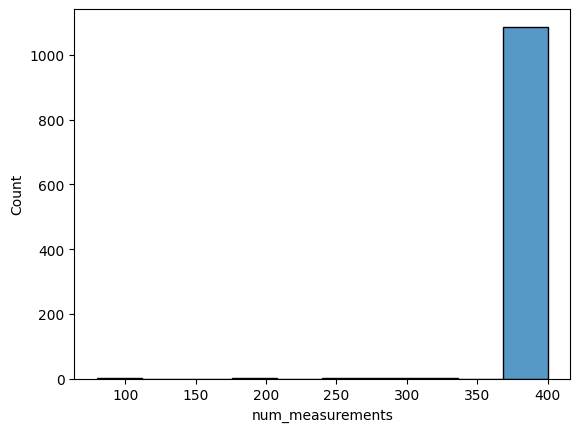

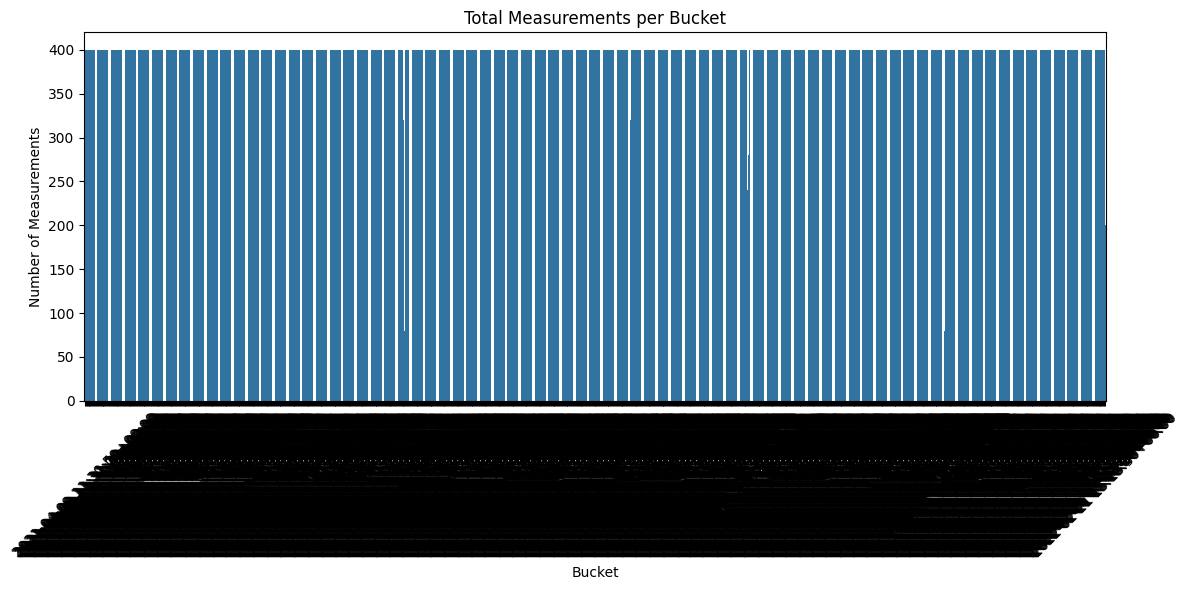

In [19]:
# Group by bucket and aggregate
bucket_counts = df.groupby('bucket')['num_measurements'].sum().reset_index()

# Bin buckets to reduce number
bucket_counts['bucket_bin'] = pd.cut(bucket_counts['num_measurements'], bins=10)
sns.histplot(bucket_counts['num_measurements'], bins=10)

# Ensure bucket is in datetime format
bucket_counts['bucket'] = pd.to_datetime(bucket_counts['bucket'])

# Sort by time
bucket_counts = bucket_counts.sort_values('bucket')

# Plot histogram by treating bucket as time series
plt.figure(figsize=(12, 6))
sns.barplot(data=bucket_counts, x='bucket', y='num_measurements')
plt.xticks(rotation=45)
plt.title('Total Measurements per Bucket')
plt.xlabel('Bucket')
plt.ylabel('Number of Measurements')
plt.tight_layout()
plt.show()

In [20]:
# Highlight outliers
outliers = df[df['num_measurements'] != 400]
print(outliers[['bucket', 'system_id', 'num_measurements']])

                          bucket         system_id  num_measurements
0      2021-04-09 11:30:50+00:00  testbed_system_1                10
1      2021-04-09 11:30:50+00:00  testbed_system_1                10
2      2021-04-09 11:30:50+00:00  testbed_system_1                10
3      2021-04-09 11:30:50+00:00  testbed_system_1                10
4      2021-04-09 11:30:50+00:00  testbed_system_1                10
...                          ...               ...               ...
43835  2022-02-21 15:13:50+00:00  testbed_system_1                 5
43836  2022-02-21 15:13:50+00:00  testbed_system_1                 5
43837  2022-02-21 15:13:50+00:00  testbed_system_1                 5
43838  2022-02-21 15:13:50+00:00  testbed_system_1                 5
43839  2022-02-21 15:13:50+00:00  testbed_system_1                 5

[43840 rows x 3 columns]


<Axes: xlabel='num_measurements', ylabel='num_attacks'>

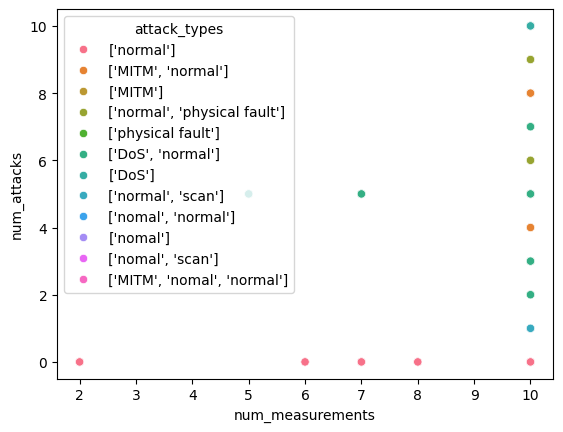

In [21]:
# Plot num_measurements vs. num_attacks
sns.scatterplot(data=df, x='num_measurements', y='num_attacks', hue='attack_types')

##B. Heatmaps (source vs. destination IPs, ports or protocols)

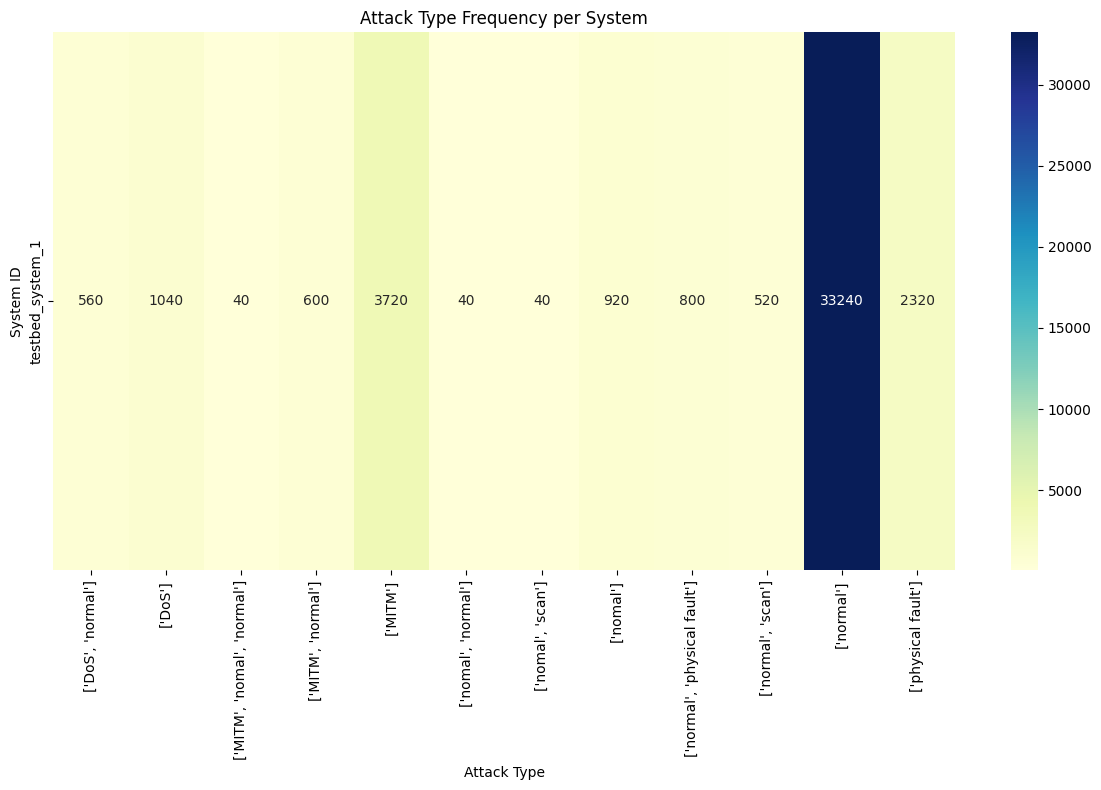

In [24]:
df_exploded = df.explode('attack_types')
crosstab = pd.crosstab(df_exploded['system_id'], df_exploded['attack_types'])

# Plot
plt.figure(figsize=(12, 8))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Attack Type Frequency per System')
plt.xlabel('Attack Type')
plt.ylabel('System ID')
plt.tight_layout()
plt.show()

##C. Distribution plots (for numeric fields)

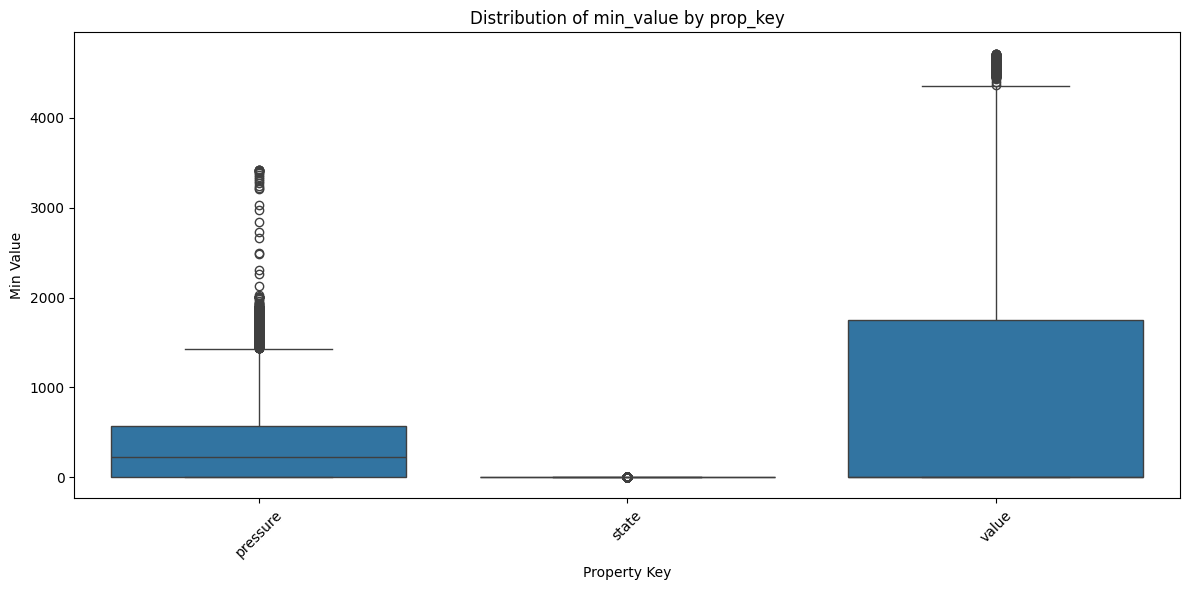

In [30]:
# Boxplot -- avg_value, min_value, max_value
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='prop_key', y='min_value')
plt.xticks(rotation=45)
plt.title('Distribution of min_value by prop_key')
plt.xlabel('Property Key')
plt.ylabel('Min Value')
plt.tight_layout()
plt.show()

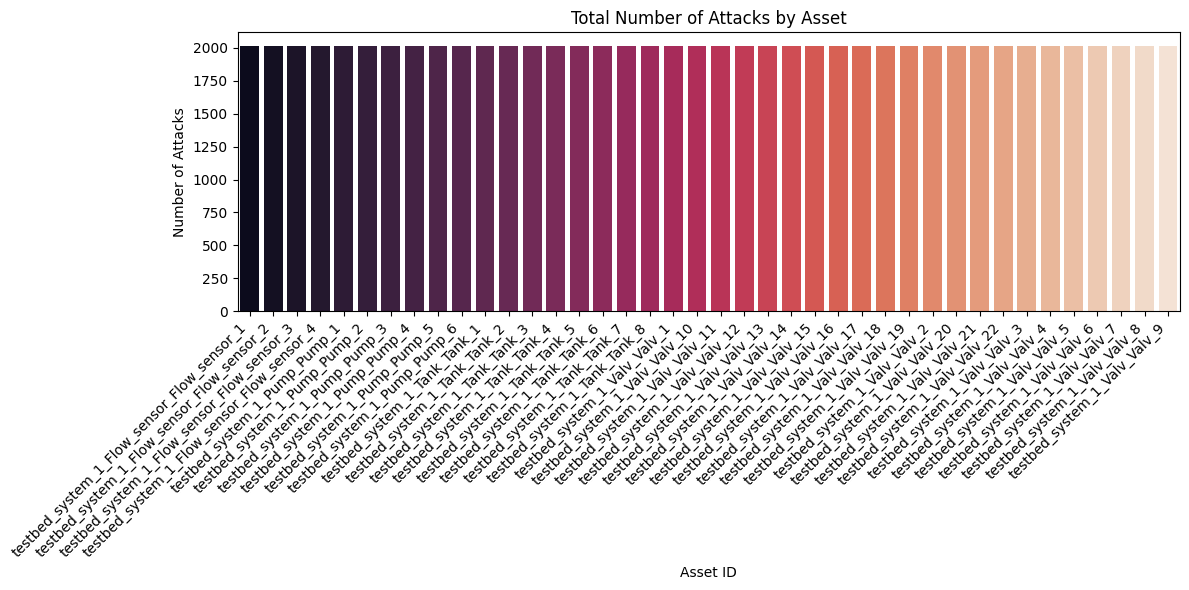

In [34]:
# Aggregate attack counts per asset
attack_counts = df.groupby('asset_id')['num_attacks'].sum().reset_index()

# Sort by attack count (optional)
attack_counts = attack_counts.sort_values('num_attacks', ascending=False)

# Plot bar chart by num_attacks per asset_id
plt.figure(figsize=(12, 6))
sns.barplot(data=attack_counts, x='asset_id', y='num_attacks', hue='asset_id', dodge=False, legend=False, palette='rocket')
plt.xticks(rotation=45, ha='right')
plt.title('Total Number of Attacks by Asset')
plt.xlabel('Asset ID')
plt.ylabel('Number of Attacks')
plt.tight_layout()
plt.show()

##D. Clustering (KMeans and DBSCAN for natural port clusters)

#4 -- Correlation Matrix

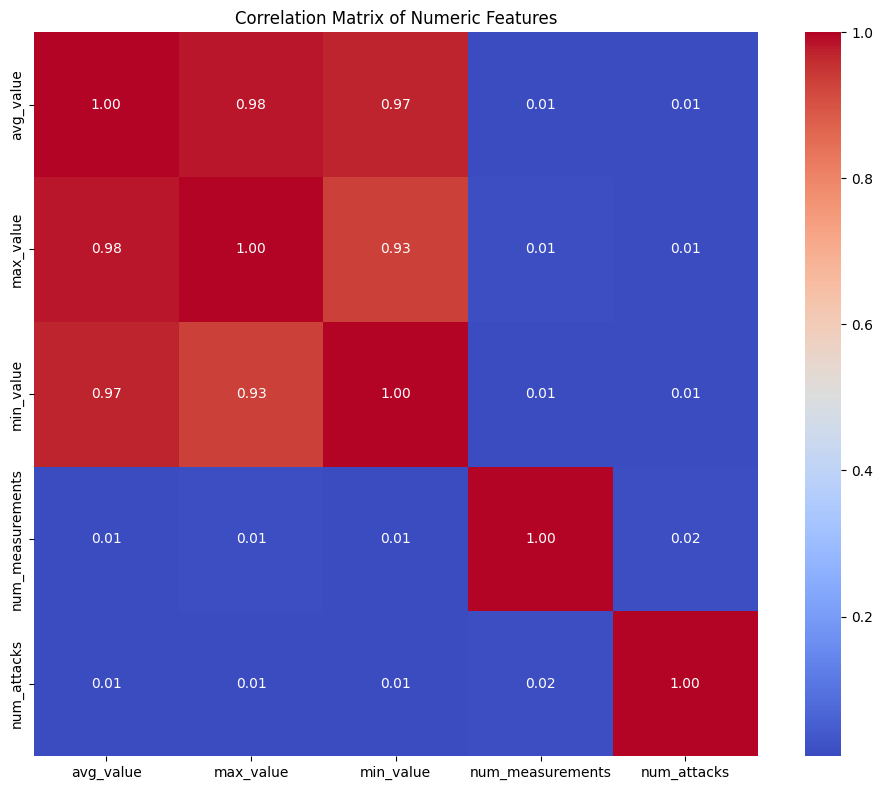

In [38]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [37]:
# Correlation matrix -- highly-correlated fields
numeric_fields = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_fields.corr()

# Filter for values above 0.8
high_corr = corr_matrix[(corr_matrix > 0.8) & (corr_matrix < 1.0)]
print(high_corr.dropna(how='all').dropna(axis=1, how='all'))

           avg_value  max_value  min_value
avg_value        NaN   0.980963   0.972154
max_value   0.980963        NaN   0.930772
min_value   0.972154   0.930772        NaN


#5 -- Feature Audit

In [ ]:
# Compare features to global_schema and identify missing useful fields

#6 -- Port Analysis

In [10]:
# Plot distribution of port_number and use clustering binning to identify natural groupings
# Consider also using histogram binning and comparing the two
# Propose bin ranges
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4).fit(df[['port_number']])
df['port_bin'] = kmeans.labels_

KeyError: "None of [Index(['port_number'], dtype='object')] are in the [columns]"

In [ ]:
# Bar chart --
sns.countplot(data=df, x='destination_key')
plt.title("Connection Counts by Destination Key")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Heatmap -- source vs. destination frequency
heatmap_data = df.groupby(['source_key', 'destination_key']).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='Blues')
plt.title("Traffic Heatmap: Source → Destination")
plt.show()

In [ ]:
# Histogram -- packet size distribution
sns.histplot(df['avg_size'], bins=50, kde=True)
plt.title("Distribution of Average Packet Size")
plt.xlabel("Packet Size (bytes)")
plt.show()

In [ ]:
# Scatter plot -- source vs. destination packet counts
sns.scatterplot(data=df, x='source_total_packets', y='destination_total_packets', hue='protocol')
plt.title("Source vs Destination Packet Counts")
plt.show()

In [ ]:
# Time series plot -- connections over time
df['bucket'] = pd.to_datetime(df['bucket'])
time_series = df.groupby('bucket')['num_connections'].sum()
time_series.plot()
plt.title("Connections Over Time")
plt.ylabel("Number of Connections")
plt.show()

In [ ]:
# Histogram/KDE plot -- reveal clustering of source port numbers
sns.histplot(df['source_port'].dropna(), bins=100, kde=True)
plt.title("Distribution of Source Port Numbers")
plt.xlabel("Port Number")
plt.ylabel("Frequency")
plt.show()